# 1. CNN с нуля на PetFaces

Задача: классификация породы по кропу морды. Параллельно сеть учит вид (кот/собака) — это auxiliary head, чтобы backbone не забывал очевидный сигнал.

В этом дампе PetFaces две директории склеили разные породы Oxford-IIIT (`dog_american`, `dog_english`)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

import petsdata as P

sns.set_theme(style="whitegrid", context="notebook")
P.set_seed(P.SEED)
device = P.get_device()
P.CKPT_DIR.mkdir(exist_ok=True)
P.RUNS_DIR.mkdir(exist_ok=True)
print("device:", device, "| seed:", P.SEED)


/Users/mnfom/Projects/cnn-Makarena-211/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps | seed: 13


## Данные


(3211, 5) breeds from filenames: 37
{'dog': 2105, 'cat': 1106}
folders with >1 breed:
folder
dog_american    2
dog_english     2
Name: breed, dtype: int64
split 2247 482 482


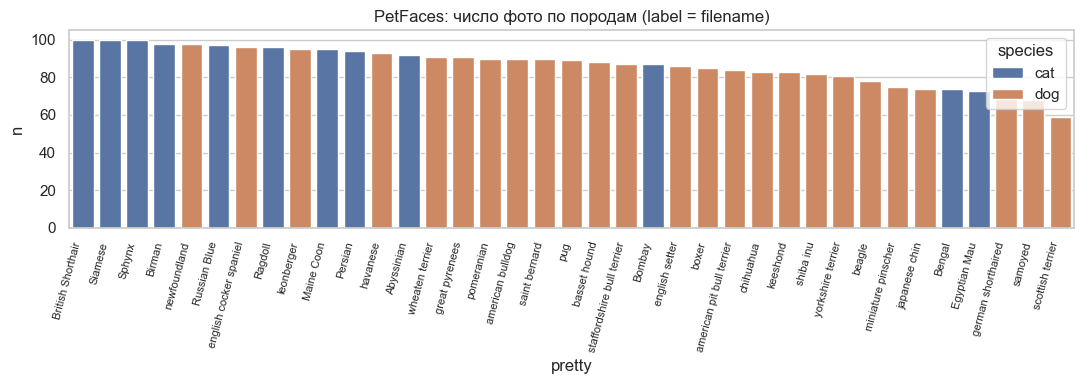

In [2]:
raw = P.scan_petfaces()
print(raw.shape, "breeds from filenames:", raw["breed"].nunique())
print(raw["species"].value_counts().to_dict())

# folder name vs real breed — вот та склейка
mismatch = raw.groupby("folder")["breed"].nunique()
print("folders with >1 breed:")
print(mismatch[mismatch > 1])

raw, breed2id, species2id = P.add_label_ids(raw)
id2breed = {i: b for b, i in breed2id.items()}
N_BREEDS = len(breed2id)

train_df, val_df, test_df = P.stratified_splits(raw)
P.save_splits(train_df, val_df, test_df, breed2id)
print("split", len(train_df), len(val_df), len(test_df))

counts = (
    raw.groupby(["species", "pretty"]).size().reset_index(name="n").sort_values("n", ascending=False)
)
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=counts, x="pretty", y="n", hue="species", ax=ax, dodge=False)
plt.setp(ax.get_xticklabels(), rotation=75, ha="right", fontsize=8)
ax.set_title("PetFaces: число фото по породам (label = filename)")
plt.tight_layout()
plt.show()


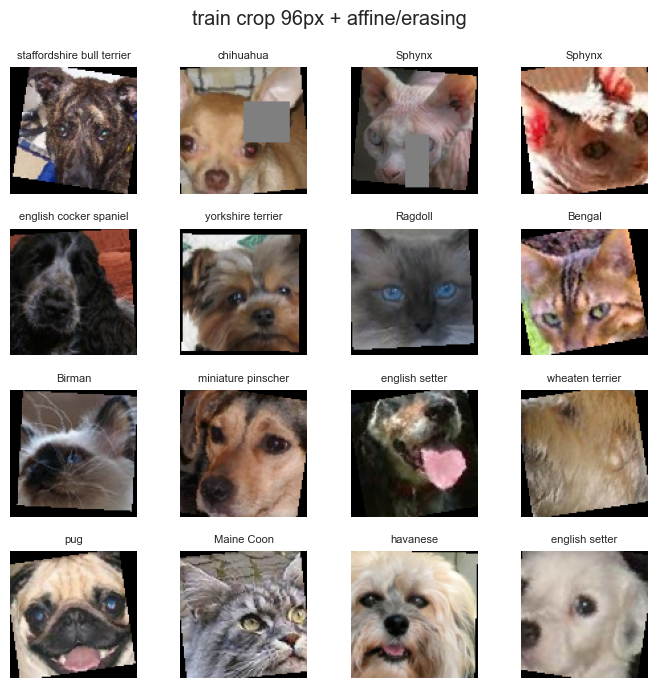

In [3]:
SIZE = 96
BATCH = 48 if device.type != "cpu" else 24
tfms = P.make_tfms(SIZE, imagenet=False, erase=True)
train_loader, val_loader, test_loader = P.make_loaders(
    train_df, val_df, test_df, tfms, batch=BATCH
)

# sanity grid
batch = next(iter(train_loader))
vis = P.denorm(batch["image"][:16], imagenet=False)
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(vis[i].permute(1, 2, 0).numpy())
    lab = id2breed[int(batch["breed"][i])]
    ax.set_title(P.pretty_label(lab), fontsize=8)
    ax.axis("off")
plt.suptitle("train crop 96px + affine/erasing")
plt.tight_layout()
plt.show()


## Архитектура

Inverted residual блоки (как в MobileNetV2), SiLU, два выхода. Не VGG-стек из одинаковых conv-pool — так проще переобучиться на 3k картинках.


In [4]:
class IRBlock(nn.Module):
    def __init__(self, cin, cout, stride=1, expand=4):
        super().__init__()
        hid = cin * expand
        self.skip = stride == 1 and cin == cout
        self.net = nn.Sequential(
            nn.Conv2d(cin, hid, 1, bias=False),
            nn.BatchNorm2d(hid),
            nn.SiLU(inplace=True),
            nn.Conv2d(hid, hid, 3, stride, 1, groups=hid, bias=False),
            nn.BatchNorm2d(hid),
            nn.SiLU(inplace=True),
            nn.Conv2d(hid, cout, 1, bias=False),
            nn.BatchNorm2d(cout),
        )

    def forward(self, x):
        y = self.net(x)
        return x + y if self.skip else y


class FaceIRNet(nn.Module):
    def __init__(self, n_breeds, n_species=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
        )
        self.stage = nn.Sequential(
            IRBlock(32, 32, 1),
            IRBlock(32, 64, 2),
            IRBlock(64, 64, 1),
            IRBlock(64, 96, 2),
            IRBlock(96, 96, 1),
            IRBlock(96, 160, 2),
            IRBlock(160, 160, 1),
            IRBlock(160, 256, 2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.35)
        self.breed = nn.Linear(256, n_breeds)
        self.species = nn.Linear(256, n_species)

    def features(self, x):
        x = self.stem(x)
        x = self.stage(x)
        return self.pool(x).flatten(1)

    def forward(self, x):
        z = self.drop(self.features(x))
        return self.breed(z), self.species(z)


net = FaceIRNet(N_BREEDS).to(device)
print("params M:", sum(p.numel() for p in net.parameters()) / 1e6)


params M: 0.786695


Mixup только для breed-головы, species считаем по исходным меткам — вид от mixup размазывать незачем.


In [5]:
def mixup(x, y, alpha=0.3):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1.0 - lam) * x[idx], y, y[idx], lam


def topk(logits, y, ks=(1, 3)):
    kmax = max(ks)
    pred = logits.topk(kmax, dim=1).indices
    hit = pred.eq(y[:, None])
    return {k: hit[:, :k].any(1).float().mean().item() for k in ks}


@torch.no_grad()
def run_eval(model, loader):
    model.eval()
    n = 0
    loss_sum = 0.0
    acc1 = acc3 = acc_sp = 0.0
    ys, ps, zs = [], [], []
    crit_b = nn.CrossEntropyLoss()
    crit_s = nn.CrossEntropyLoss()
    for batch in loader:
        x = batch["image"].to(device)
        yb = batch["breed"].to(device)
        ys_ = batch["species"].to(device)
        lb, ls = model(x)
        loss = crit_b(lb, yb) + 0.4 * crit_s(ls, ys_)
        bs = x.size(0)
        n += bs
        loss_sum += loss.item() * bs
        tk = topk(lb, yb, (1, 3))
        acc1 += tk[1] * bs
        acc3 += tk[3] * bs
        acc_sp += (ls.argmax(1) == ys_).float().mean().item() * bs
        ys.append(yb.cpu())
        ps.append(lb.softmax(1).cpu())
        zs.append(ls.argmax(1).cpu())
    return {
        "loss": loss_sum / n,
        "top1": acc1 / n,
        "top3": acc3 / n,
        "species": acc_sp / n,
        "y": torch.cat(ys).numpy(),
        "prob": torch.cat(ps).numpy(),
        "species_hat": torch.cat(zs).numpy(),
    }


def run_train_epoch(model, loader, opt, scaler, w_breed):
    model.train()
    n = 0
    loss_sum = 0.0
    crit_b = nn.CrossEntropyLoss(weight=w_breed, label_smoothing=0.05)
    crit_s = nn.CrossEntropyLoss()
    for batch in tqdm(loader, leave=False):
        x = batch["image"].to(device)
        yb = batch["breed"].to(device)
        ys_ = batch["species"].to(device)
        x, ya, yb2, lam = mixup(x, yb, alpha=0.25)
        opt.zero_grad(set_to_none=True)
        lb, ls = model(x)
        loss_b = lam * crit_b(lb, ya) + (1.0 - lam) * crit_b(lb, yb2)
        loss = loss_b + 0.4 * crit_s(ls, ys_)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        bs = x.size(0)
        n += bs
        loss_sum += loss.item() * bs
    return loss_sum / n


01 loss 3.766/3.653  top1 0.135 top3 0.299  species 0.683  lr 2.98e-03 *


02 loss 3.384/3.195  top1 0.191 top3 0.405  species 0.753  lr 2.91e-03 *


03 loss 3.140/2.529  top1 0.342 top3 0.598  species 0.790  lr 2.80e-03 *


04 loss 2.988/2.660  top1 0.340 top3 0.598  species 0.743  lr 2.65e-03 


05 loss 2.875/2.402  top1 0.371 top3 0.627  species 0.797  lr 2.46e-03 *


...

14 loss 2.021/1.336  top1 0.641 top3 0.857  species 0.936  lr 3.51e-04 *


15 loss 2.122/1.340  top1 0.649 top3 0.855  species 0.942  lr 2.01e-04 *


16 loss 2.086/1.292  top1 0.643 top3 0.863  species 0.952  lr 9.05e-05 


17 loss 1.908/1.269  top1 0.670 top3 0.857  species 0.948  lr 2.28e-05 *


18 loss 2.002/1.266  top1 0.662 top3 0.859  species 0.952  lr 0.00e+00 


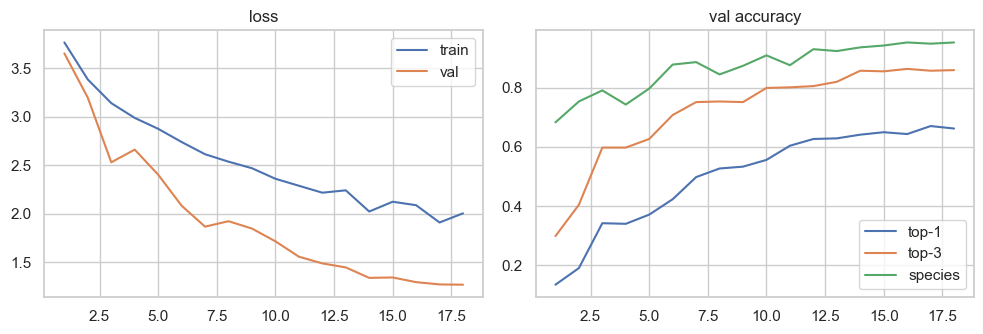

In [6]:
EPOCHS = 18
w_breed = P.class_weights(train_df, N_BREEDS).to(device)
opt = torch.optim.AdamW(net.parameters(), lr=3e-3, weight_decay=4e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = []
best = -1.0
ckpt = P.CKPT_DIR / "faceirnet.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss = run_train_epoch(net, train_loader, opt, None, w_breed)
    va = run_eval(net, val_loader)
    sched.step()
    history.append(
        {
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va["loss"],
            "val_top1": va["top1"],
            "val_top3": va["top3"],
            "val_species": va["species"],
            "lr": opt.param_groups[0]["lr"],
        }
    )
    star = ""
    if va["top1"] > best:
        best = va["top1"]
        star = "*"
        torch.save(
            {"state": net.state_dict(), "breed2id": breed2id, "epoch": epoch, "val_top1": best},
            ckpt,
        )
    print(
        f"{epoch:02d} loss {tr_loss:.3f}/{va['loss']:.3f}  "
        f"top1 {va['top1']:.3f} top3 {va['top3']:.3f}  "
        f"species {va['species']:.3f}  lr {opt.param_groups[0]['lr']:.2e} {star}"
    )

hist = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(hist.epoch, hist.train_loss, label="train")
ax[0].plot(hist.epoch, hist.val_loss, label="val")
ax[0].set_title("loss")
ax[0].legend()
ax[1].plot(hist.epoch, hist.val_top1, label="top-1")
ax[1].plot(hist.epoch, hist.val_top3, label="top-3")
ax[1].plot(hist.epoch, hist.val_species, label="species")
ax[1].set_title("val accuracy")
ax[1].legend()
plt.tight_layout()
plt.show()


## Тест


test top-1 0.6618 | top-3 0.8734 | species head 0.9315
species via breed argmax: 0.946058091286307
                            precision    recall  f1-score   support

                Abyssinian       0.77      0.71      0.74        14
                    Bengal       0.67      0.55      0.60        11
                    Birman       0.63      0.86      0.73        14
                    Bombay       0.85      0.85      0.85        13
         British Shorthair       0.79      0.73      0.76        15
              Egyptian Mau       0.62      0.73      0.67        11
                Maine Coon       0.92      0.79      0.85        14
                   Persian       0.87      0.93      0.90        14
                   Ragdoll       0.78      0.47      0.58        15
              Russian Blue       0.69      0.73      0.71        15
                   Siamese       0.53      0.53      0.53        15
                    Sphynx       0.50      0.67      0.57        15
          americ

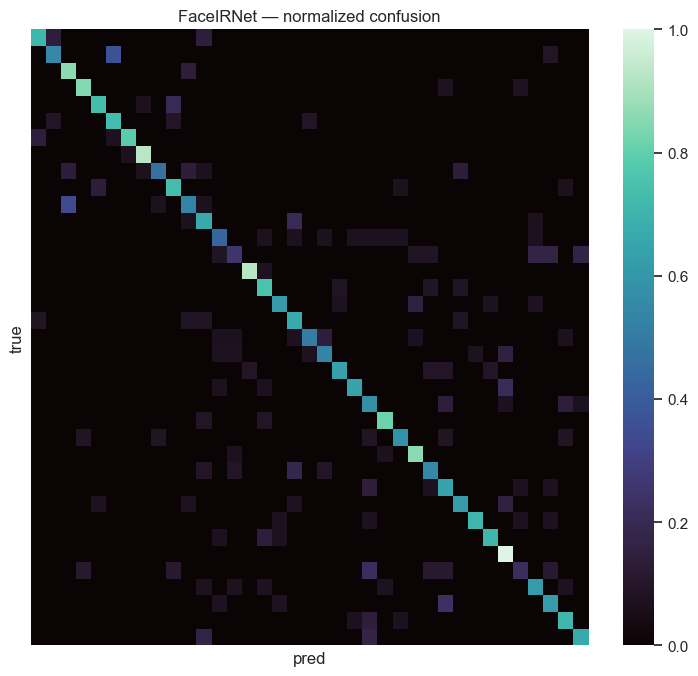

most confused:
  Siamese -> Birman  (5)
  Bengal -> Egyptian Mau  (4)
  great pyrenees -> samoyed  (3)
  staffordshire bull terrier -> newfoundland  (3)
  Sphynx -> chihuahua  (3)
  British Shorthair -> Russian Blue  (3)
  Ragdoll -> pomeranian  (2)
  Birman -> Siamese  (2)


In [7]:
blob = torch.load(ckpt, map_location=device, weights_only=False)
net.load_state_dict(blob["state"])
te = run_eval(net, test_loader)
print(
    f"test top-1 {te['top1']:.4f} | top-3 {te['top3']:.4f} | species head {te['species']:.4f}"
)

breed_to_species = (
    raw.groupby("breed_id")["species_id"].agg(lambda s: int(s.mode().iloc[0])).to_dict()
)
y_hat = te["prob"].argmax(1)
sp_from_breed = np.array([breed_to_species[int(i)] for i in y_hat])
sp_true = test_df["species_id"].values
print("species via breed argmax:", (sp_from_breed == sp_true).mean())

names = [P.pretty_label(id2breed[i]) for i in range(N_BREEDS)]
print(classification_report(te["y"], y_hat, target_names=names, zero_division=0))

cm = confusion_matrix(te["y"], y_hat, labels=np.arange(N_BREEDS))
cm_n = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
plt.figure(figsize=(9, 8))
sns.heatmap(cm_n, cmap="mako", xticklabels=False, yticklabels=False, vmin=0, vmax=1)
plt.title("FaceIRNet — normalized confusion")
plt.xlabel("pred")
plt.ylabel("true")
plt.show()

# частые путаницы
off = cm.copy()
np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:8], off.shape))[0]
print("most confused:")
for i, j in pairs:
    if off[i, j] == 0:
        break
    print(f"  {names[i]} -> {names[j]}  ({off[i, j]})")


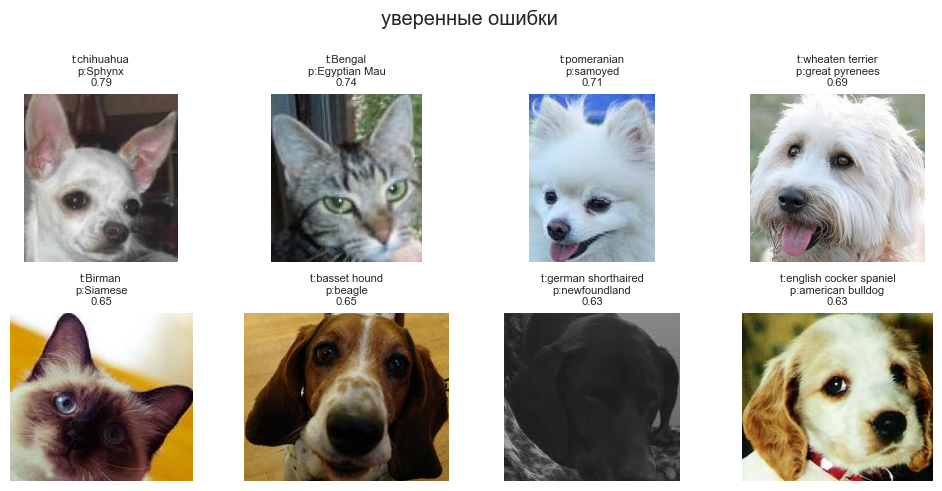

In [8]:
# ошибки: модель уверена, но неправа
conf = te["prob"].max(1)
wrong = np.where(y_hat != te["y"])[0]
order = wrong[np.argsort(-conf[wrong])][:8]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), order):
    row = test_df.iloc[idx]
    img = plt.imread(row["path"])
    ax.imshow(img)
    ax.set_title(
        f"t:{P.pretty_label(id2breed[int(row.breed_id)])}\np:{names[y_hat[idx]]}\n{conf[idx]:.2f}",
        fontsize=8,
    )
    ax.axis("off")
plt.suptitle("уверенные ошибки")
plt.tight_layout()
plt.show()
